# LVL1 Data Loading Demonstration

This notebook demonstrates how to load the processed LVL1 dataset with the **new sensor_idx structure** (updated October 2025) that combines all sensor data into a unified format.

## Overview

The JIFLR project has been refactored to use an efficient sensor_idx structure that:

1. **Replaces sparse arrays**: Old `(site_id × height × shielding × datetime)` → New `(sensor_idx, datetime)`
2. **Reduces memory usage**: ~83% reduction compared to sparse structure  
3. **Preserves metadata**: All sensor attributes stored as coordinates indexed by sensor_idx
4. **Enables natural operations**: Direct sensor filtering using `ds.where()`

## Key Changes from Old Structure

- **Dimensions**: `sensor_idx` × `datetime` (was: site_id × height × shielding × datetime)
- **Metadata storage**: Coordinates indexed by sensor_idx (was: sparse array dimensions)
- **Data access**: `ds.where(ds.site_id == 'A01')` (was: `ds.sel(site_id='A01')`)
- **Memory efficiency**: Only stores data where sensors actually exist

This demo shows how to work with the combined dataset containing both pendant and pace sensor data.

In [83]:
import warnings
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path

from jiflr import ROOT

plt.style.use('default')
print(f"Project root: {ROOT}")

Project root: /Users/drotto/src/jiflr


## Load the Combined LVL1 Dataset

Load the processed LVL1 dataset that combines all sensor data in the new sensor_idx structure:

In [84]:
# Load the combined LVL1 dataset with sensor_idx structure
data_path = Path(ROOT) / "data" / "2025" / "processed" / "lvl1" / "lvl1_combined.nc"
ds = xr.open_dataset(data_path)

# Display basic information
print("Combined LVL1 dataset overview:")
print(ds)
print(f"\nDataset file size: {data_path.stat().st_size / (1024**3):.2f} GB")

Combined LVL1 dataset overview:
<xarray.Dataset> Size: 106MB
Dimensions:            (sensor_idx: 104, datetime: 18090)
Coordinates:
  * datetime           (datetime) datetime64[ns] 145kB 2025-06-11T15:00:00 .....
    site_id            (sensor_idx) <U9 4kB ...
    height             (sensor_idx) <U4 2kB ...
    shielding          (sensor_idx) <U10 4kB ...
    sensor_type        (sensor_idx) <U4 2kB ...
    sensor_generation  (sensor_idx) <U11 5kB ...
    sensor_id          (sensor_idx) <U28 12kB ...
    elevation          (sensor_idx) float64 832B ...
    latitude           (sensor_idx) float64 832B ...
    longitude          (sensor_idx) float64 832B ...
  * sensor_idx         (sensor_idx) int64 832B 0 1 2 3 4 ... 99 100 101 102 103
Data variables:
    temp_c             (sensor_idx, datetime) float64 15MB ...
    wind_direction     (sensor_idx, datetime) float64 15MB ...
    pressure           (sensor_idx, datetime) float64 15MB ...
    relative_humidity  (sensor_idx, datetime) float

## Explore the New Dataset Structure

In [85]:
# Examine the new sensor_idx structure
print("Dataset dimensions:")
for dim, size in ds.sizes.items():
    print(f"  {dim}: {size}")

print("\nData variables and their dimensions:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims}")

print("\nCoordinates (sensor metadata):")
for coord in ds.coords:
    if coord != 'datetime_utc' and coord != 'sensor_idx':
        print(f"  {coord}: {ds[coord].dims}")

Dataset dimensions:
  sensor_idx: 104
  datetime: 18090

Data variables and their dimensions:
  temp_c: ('sensor_idx', 'datetime')
  wind_direction: ('sensor_idx', 'datetime')
  pressure: ('sensor_idx', 'datetime')
  relative_humidity: ('sensor_idx', 'datetime')
  wind_speed_avg: ('sensor_idx', 'datetime')
  wind_speed_peak: ('sensor_idx', 'datetime')
  intensity_lux: ('sensor_idx', 'datetime')

Coordinates (sensor metadata):
  datetime: ('datetime',)
  site_id: ('sensor_idx',)
  height: ('sensor_idx',)
  shielding: ('sensor_idx',)
  sensor_type: ('sensor_idx',)
  sensor_generation: ('sensor_idx',)
  sensor_id: ('sensor_idx',)
  elevation: ('sensor_idx',)
  latitude: ('sensor_idx',)
  longitude: ('sensor_idx',)


In [86]:
# Examine sensor metadata
print("Sensor metadata summary:")
print(f"Total sensors: {len(ds.sensor_idx)}")

# Get unique values for each metadata attribute
unique_sites = np.unique(ds.site_id.values)
unique_heights = np.unique(ds.height.values)
unique_shielding = np.unique(ds.shielding.values)
unique_sensor_types = np.unique(ds.sensor_type.values)

print(f"Unique sites: {len(unique_sites)} - {list(unique_sites)}")
print(f"Unique heights: {len(unique_heights)} - {list(unique_heights)}")
print(f"Unique shielding types: {len(unique_shielding)} - {list(unique_shielding)}")
print(f"Unique sensor types: {len(unique_sensor_types)} - {list(unique_sensor_types)}")

# Show first few sensors as examples
print(f"\nFirst 10 sensors (example):")
for i in range(min(10, len(ds.sensor_idx))):
    site = ds.site_id.values[i]
    height = ds.height.values[i]
    shielding = ds.shielding.values[i]
    sensor_type = ds.sensor_type.values[i]
    sensor_id = ds.sensor_id.values[i]
    print(f"  {i:2}: {site:8} {height:4} {shielding:10} {sensor_type:12} (ID: {sensor_id})")

Sensor metadata summary:
Total sensors: 104
Unique sites: 31 - [np.str_('A01'), np.str_('A02'), np.str_('A03'), np.str_('A04'), np.str_('A05'), np.str_('A06'), np.str_('A07'), np.str_('A08'), np.str_('A10'), np.str_('B01'), np.str_('B02'), np.str_('B03'), np.str_('C02'), np.str_('D01'), np.str_('D02'), np.str_('D04'), np.str_('Divide'), np.str_('E01'), np.str_('E03'), np.str_('E04'), np.str_('F03'), np.str_('F05'), np.str_('F06'), np.str_('G01'), np.str_('G02'), np.str_('G03'), np.str_('G04'), np.str_('Lee1'), np.str_('Lee2'), np.str_('Windward1'), np.str_('Windward2')]
Unique heights: 7 - [np.str_('0.5m'), np.str_('0m'), np.str_('1.0m'), np.str_('1.5m'), np.str_('1m'), np.str_('2.0m'), np.str_('2m')]
Unique shielding types: 2 - [np.str_('shielded'), np.str_('unshielded')]
Unique sensor types: 2 - [np.str_('hobo'), np.str_('pace')]

First 10 sensors (example):
   0: Windward1 2.0m unshielded pace         (ID: EM54054_2.0m_temperature)
   1: Windward1 1.5m unshielded pace         (ID: E

## Time Range Analysis

In [87]:
# Convert datetime to pandas datetime for easier analysis
time_vals = pd.to_datetime(ds.datetime.values)

print(f"Time range: {time_vals.min()} to {time_vals.max()}")
print(f"Total time points: {len(time_vals)}")
print(f"Time resolution: {pd.Series(time_vals).diff().mode().iloc[0]}")
print(f"Deployment duration: {(time_vals.max() - time_vals.min()).days} days")

Time range: 2025-06-11 15:00:00 to 2025-08-13 10:25:00
Total time points: 18090
Time resolution: 0 days 00:05:00
Deployment duration: 62 days


## Data Availability Analysis Using New Structure

In [88]:
# Analyze temperature data availability by sensor using the new structure
print("Temperature data availability analysis:")
print("=" * 50)

# Calculate data availability for each sensor
sensor_availability = []
for sensor_idx in range(len(ds.sensor_idx)):
    temp_data = ds.temp_c.isel(sensor_idx=sensor_idx)
    total_possible = len(ds.datetime)
    available = np.sum(~np.isnan(temp_data.values))
    availability_pct = (available / total_possible) * 100
    
    site_id = ds.site_id.values[sensor_idx]
    height = ds.height.values[sensor_idx]
    shielding = ds.shielding.values[sensor_idx]
    sensor_type = ds.sensor_type.values[sensor_idx]
    
    sensor_availability.append({
        'sensor_idx': sensor_idx,
        'site_id': site_id,
        'height': height,
        'shielding': shielding,
        'sensor_type': sensor_type,
        'data_points': available,
        'availability_pct': availability_pct
    })

# Convert to DataFrame for analysis
availability_df = pd.DataFrame(sensor_availability)

# Display top sensors by data availability
print("Top 10 sensors by data availability:")
top_sensors = availability_df.nlargest(10, 'availability_pct')
print(top_sensors[['site_id', 'height', 'shielding', 'sensor_type', 'data_points', 'availability_pct']].to_string(index=False))

# Summary by site
print(f"\nSite-level summary:")
site_summary = availability_df.groupby('site_id').agg({
    'sensor_idx': 'count',
    'data_points': 'sum',
    'availability_pct': 'mean'
}).round(2)
site_summary.columns = ['sensor_count', 'total_data_points', 'avg_availability_pct']
print(site_summary.head(10).to_string())

Temperature data availability analysis:
Top 10 sensors by data availability:
site_id height shielding sensor_type  data_points  availability_pct
   Lee2     2m  shielded        hobo        16383         90.563847
 Divide     2m  shielded        hobo        12920         71.420674
    A10     1m  shielded        hobo         3333         18.424544
    A10     2m  shielded        hobo         3333         18.424544
    A07     1m  shielded        hobo          952          5.262576
    A07     2m  shielded        hobo          952          5.262576
    A08     2m  shielded        hobo          371          2.050857
    A08     1m  shielded        hobo          371          2.050857
    A05     2m  shielded        hobo          174          0.961857
    A05     1m  shielded        hobo          174          0.961857

Site-level summary:
         sensor_count  total_data_points  avg_availability_pct
site_id                                                       
A01                 1       

## Demonstrate New Data Access Patterns

In [89]:
# Demonstrate the new data access patterns with sensor_idx structure
print("New Data Access Patterns with sensor_idx structure:")
print("=" * 55)

# Pattern 1: Filter by site
print("1. Site-based filtering:")
site_a01 = ds.where(ds.site_id == "A01", drop=True)
print(f"   Site A01: {len(site_a01.sensor_idx)} sensors")

# Pattern 2: Filter by height
print("\n2. Height-based filtering:")
sensors_2m = ds.where(ds.height == "2m", drop=True)
print(f"   2m sensors: {len(sensors_2m.sensor_idx)} sensors across {len(np.unique(sensors_2m.site_id.values))} sites")

# Pattern 3: Filter by sensor type
print("\n3. Sensor type filtering:")
pendant_sensors = ds.where(ds.sensor_type == "hobo", drop=True)
pace_sensors = ds.where(ds.sensor_type == "pace", drop=True)
print(f"   HOBO pendant sensors: {len(pendant_sensors.sensor_idx)}")
print(f"   Pace sensors: {len(pace_sensors.sensor_idx)}")

# Pattern 4: Complex filtering (combine multiple conditions)
print("\n4. Complex filtering (2m shielded pendant sensors):")
complex_filter = ds.where(
    (ds.height == "2m") & 
    (ds.shielding == "shielded") & 
    (ds.sensor_type == "hobo"), 
    drop=True
)
print(f"   Matching sensors: {len(complex_filter.sensor_idx)}")
if len(complex_filter.sensor_idx) > 0:
    print(f"   Sites: {list(np.unique(complex_filter.site_id.values))}")

# Pattern 5: Multi-site selection
print("\n5. Multi-site selection:")
multi_sites = ds.where(ds.site_id.isin(["A01", "A02", "A03", "B01"]), drop=True)
print(f"   Selected sites A01-A03, B01: {len(multi_sites.sensor_idx)} sensors")

# Pattern 6: Time slicing (works the same as before)
print("\n6. Time slicing (July 2025):")
july_data = ds.sel(datetime=slice("2025-07-01", "2025-07-31"))
print(f"   July data: {july_data.temp_c.shape}")

# Show memory efficiency
print(f"\n7. Memory efficiency comparison:")
print(f"   New structure: {len(ds.sensor_idx)} × {len(ds.datetime)} = {len(ds.sensor_idx) * len(ds.datetime):,} elements")
print(f"   Old structure would be: {len(unique_sites)} × {len(unique_heights)} × {len(unique_shielding)} × {len(ds.datetime)} = {len(unique_sites) * len(unique_heights) * len(unique_shielding) * len(ds.datetime):,} elements")
print(f"   Memory reduction: ~{(1 - (len(ds.sensor_idx) * len(ds.datetime)) / (len(unique_sites) * len(unique_heights) * len(unique_shielding) * len(ds.datetime))) * 100:.1f}%")

New Data Access Patterns with sensor_idx structure:
1. Site-based filtering:
   Site A01: 1 sensors

2. Height-based filtering:
   2m sensors: 50 sensors across 30 sites

3. Sensor type filtering:
   HOBO pendant sensors: 59
   Pace sensors: 45

4. Complex filtering (2m shielded pendant sensors):
   Matching sensors: 30
   Sites: [np.str_('A02'), np.str_('A03'), np.str_('A04'), np.str_('A05'), np.str_('A06'), np.str_('A07'), np.str_('A08'), np.str_('A10'), np.str_('B01'), np.str_('B02'), np.str_('B03'), np.str_('C02'), np.str_('D01'), np.str_('D02'), np.str_('D04'), np.str_('Divide'), np.str_('E01'), np.str_('E03'), np.str_('E04'), np.str_('F03'), np.str_('F05'), np.str_('F06'), np.str_('G01'), np.str_('G02'), np.str_('G03'), np.str_('G04'), np.str_('Lee1'), np.str_('Lee2'), np.str_('Windward1'), np.str_('Windward2')]

5. Multi-site selection:
   Selected sites A01-A03, B01: 8 sensors

6. Time slicing (July 2025):
   July data: (104, 8928)

7. Memory efficiency comparison:
   New struc

## Visualize Sensor Distribution

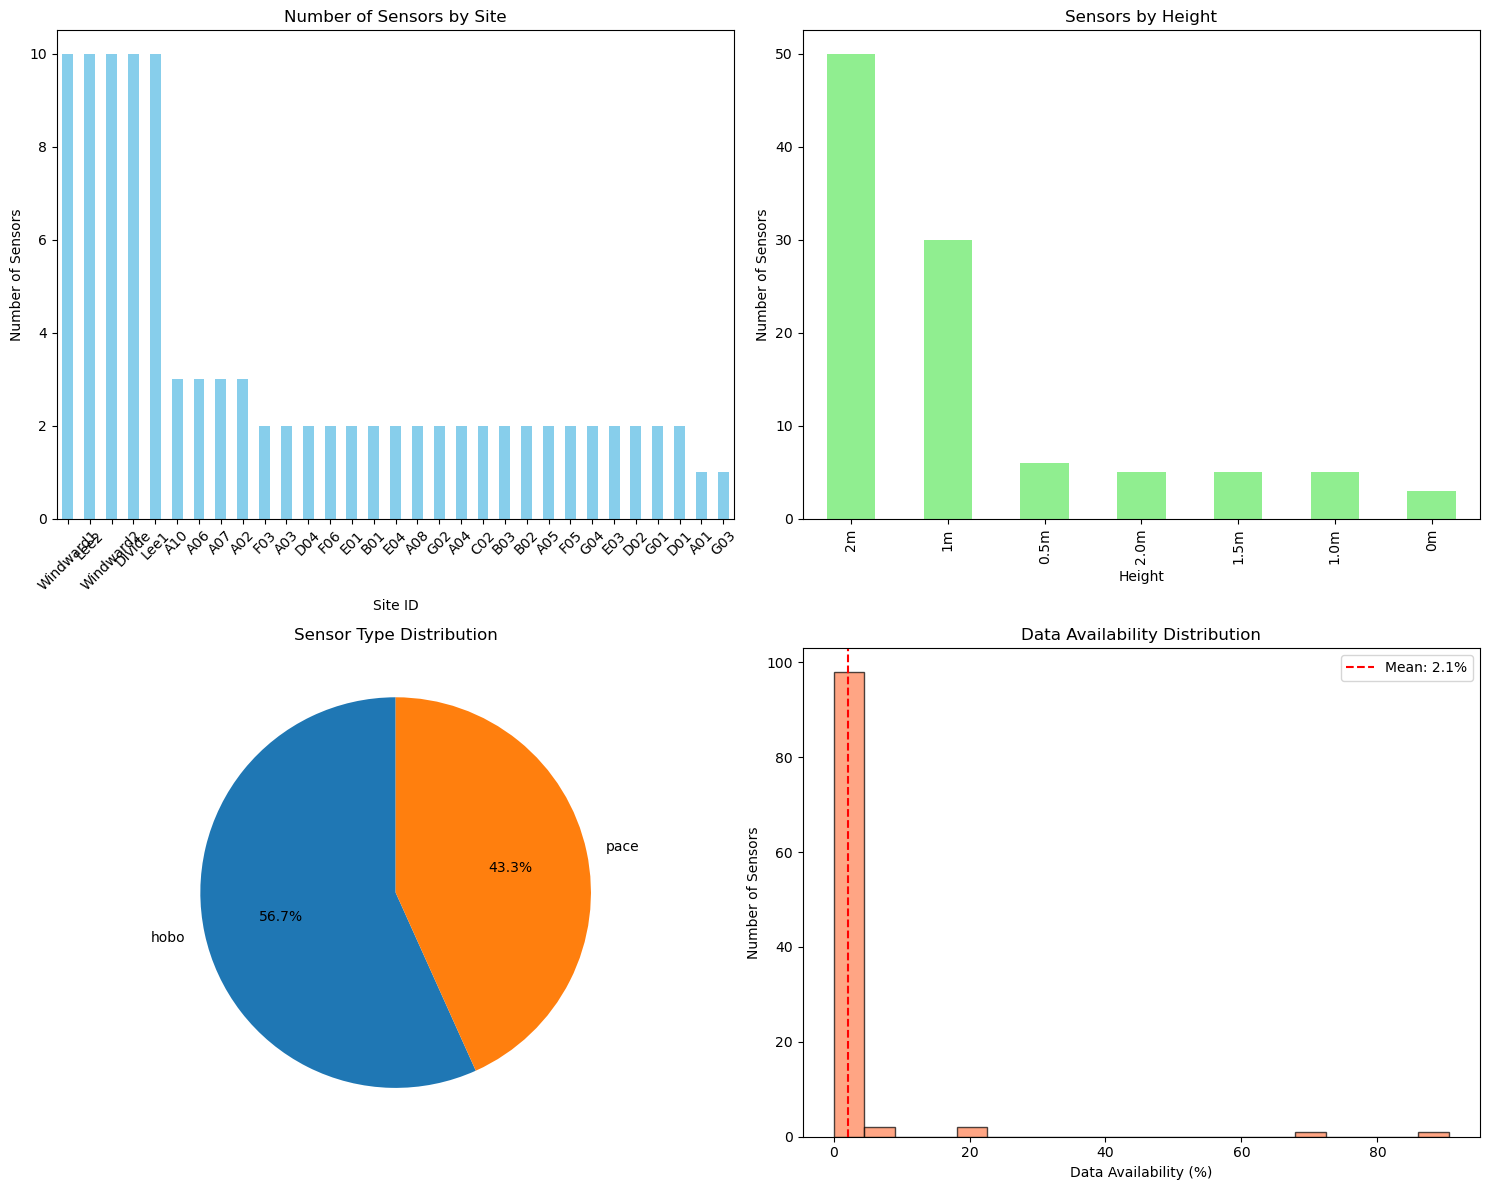


Sensor Distribution Summary:
Total unique sites: 31
Total sensors: 104
Average sensors per site: 3.4
Sensor types: {np.str_('hobo'): np.int64(59), np.str_('pace'): np.int64(45)}
Height distribution: {np.str_('2m'): np.int64(50), np.str_('1m'): np.int64(30), np.str_('0.5m'): np.int64(6), np.str_('2.0m'): np.int64(5), np.str_('1.5m'): np.int64(5), np.str_('1.0m'): np.int64(5), np.str_('0m'): np.int64(3)}
Average data availability: 2.1%


In [90]:
# Create visualizations showing sensor distribution
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Sensors by site
site_counts = availability_df['site_id'].value_counts()
site_counts.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Number of Sensors by Site')
ax1.set_xlabel('Site ID')
ax1.set_ylabel('Number of Sensors')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Sensors by height
height_counts = availability_df['height'].value_counts()
height_counts.plot(kind='bar', ax=ax2, color='lightgreen')
ax2.set_title('Sensors by Height')
ax2.set_xlabel('Height')
ax2.set_ylabel('Number of Sensors')

# Plot 3: Sensors by type
type_counts = availability_df['sensor_type'].value_counts()
type_counts.plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
ax3.set_title('Sensor Type Distribution')
ax3.set_ylabel('')

# Plot 4: Data availability histogram
ax4.hist(availability_df['availability_pct'], bins=20, color='coral', alpha=0.7, edgecolor='black')
ax4.set_title('Data Availability Distribution')
ax4.set_xlabel('Data Availability (%)')
ax4.set_ylabel('Number of Sensors')
ax4.axvline(availability_df['availability_pct'].mean(), color='red', linestyle='--', 
           label=f'Mean: {availability_df["availability_pct"].mean():.1f}%')
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSensor Distribution Summary:")
print(f"Total unique sites: {len(unique_sites)}")
print(f"Total sensors: {len(ds.sensor_idx)}")
print(f"Average sensors per site: {len(ds.sensor_idx) / len(unique_sites):.1f}")
print(f"Sensor types: {dict(type_counts)}")
print(f"Height distribution: {dict(height_counts)}")
print(f"Average data availability: {availability_df['availability_pct'].mean():.1f}%")

## Sample Temperature Analysis with New Structure

# Plot temperature time series for sensors with highest data availability
top_4_sensors = availability_df.nlargest(4, 'availability_pct')

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, (_, sensor_info) in enumerate(top_4_sensors.iterrows()):
    ax = axes[i]
    sensor_idx = sensor_info['sensor_idx']
    
    # Get temperature data for this sensor
    temp_data = ds.temp_c.isel(sensor_idx=sensor_idx).dropna("datetime")
    
    if len(temp_data) > 0:
        ax.plot(temp_data.datetime, temp_data.values, alpha=0.7, linewidth=0.8)
        
        # Add title with sensor info
        site_id = sensor_info['site_id']
        height = sensor_info['height']
        sensor_type = sensor_info['sensor_type']
        shielding = sensor_info['shielding']
        availability = sensor_info['availability_pct']
        
        ax.set_title(f'{site_id} @ {height} ({sensor_type})\n{shielding}, {availability:.1f}% data available')
        ax.set_ylabel('Temperature (°C)')
        ax.grid(True, alpha=0.3)
        
        # Format x-axis
        ax.tick_params(axis='x', rotation=45)

# Set common xlabel for bottom plots
axes[2].set_xlabel('Date')
axes[3].set_xlabel('Date')

plt.suptitle('Temperature Time Series: Top 4 Sensors by Data Availability\n(sensor_idx structure)', fontsize=14)
plt.tight_layout()
plt.show()

# Calculate overall temperature statistics
print(f"\nOverall Temperature Statistics:")
print(f"Mean temperature: {ds.temp_c.mean(skipna=True).values:.2f}°C")
print(f"Temperature range: {ds.temp_c.min(skipna=True).values:.2f}°C to {ds.temp_c.max(skipna=True).values:.2f}°C")
print(f"Standard deviation: {ds.temp_c.std(skipna=True).values:.2f}°C")

# Compare by sensor type
pendant_temp = pendant_sensors.temp_c.mean(skipna=True)
pace_temp = pace_sensors.temp_c.mean(skipna=True)
print(f"\nTemperature by sensor type:")
print(f"HOBO pendant sensors: {float(pendant_temp):.2f}°C")
print(f"Pace sensors: {float(pace_temp):.2f}°C")

## Advanced Analysis: Height-based Temperature Differences

Demonstrate analysis capabilities enabled by the new sensor_idx structure.

In [93]:
# Analyze temperature differences between heights using the new structure
print("Height-based Temperature Analysis (using sensor_idx structure):")
print("=" * 65)

# Find sites with sensors at multiple heights
sites_with_multiple_heights = []
for site in unique_sites:
    if site:  # Skip empty site names
        site_sensors = ds.where(ds.site_id == site, drop=True)
        site_heights = np.unique(site_sensors.height.values)
        if len(site_heights) > 1:
            sites_with_multiple_heights.append({
                'site': site, 
                'heights': list(site_heights),
                'n_heights': len(site_heights)
            })

print(f"Sites with multiple height levels: {len(sites_with_multiple_heights)}")
for site_info in sites_with_multiple_heights[:10]:  # Show first 10
    print(f"  {site_info['site']}: {site_info['heights']} ({site_info['n_heights']} heights)")

# Analyze temperature differences between 1m and 2m sensors
print(f"\nTemperature difference analysis (2m - 1m):")
height_diffs = []

for site in unique_sites:
    if site:
        try:
            # Get 1m and 2m sensors at this site
            site_1m = ds.where((ds.site_id == site) & (ds.height == "1m"), drop=True)
            site_2m = ds.where((ds.site_id == site) & (ds.height == "2m"), drop=True)
            
            if len(site_1m.sensor_idx) > 0 and len(site_2m.sensor_idx) > 0:
                # Take first sensor of each height (or could average multiple)
                temp_1m = site_1m.temp_c.isel(sensor_idx=0).dropna("datetime")
                temp_2m = site_2m.temp_c.isel(sensor_idx=0).dropna("datetime")
                
                # Align and calculate difference
                if len(temp_1m) > 100 and len(temp_2m) > 100:  # Ensure sufficient data
                    aligned_1m, aligned_2m = xr.align(temp_1m, temp_2m, join='inner')
                    if len(aligned_1m) > 50:
                        temp_diff = aligned_2m - aligned_1m
                        mean_diff = float(temp_diff.mean())
                        std_diff = float(temp_diff.std())
                        n_points = len(aligned_1m)
                        
                        height_diffs.append({
                            'site': site,
                            'mean_diff': mean_diff,
                            'std_diff': std_diff,
                            'n_points': n_points
                        })
        except:
            warnings.warn(f"Missing sensor data at {site} to do difference analysis")

# Display results
height_diffs_df = pd.DataFrame(height_diffs)
if len(height_diffs_df) > 0:
    print(f"Sites with 1m-2m temperature comparison:")
    print(height_diffs_df.round(3).to_string(index=False))
    
    print(f"\nOverall height difference statistics:")
    print(f"Mean difference (2m - 1m): {height_diffs_df['mean_diff'].mean():.3f} ± {height_diffs_df['mean_diff'].std():.3f}°C")
    print(f"Range: {height_diffs_df['mean_diff'].min():.3f} to {height_diffs_df['mean_diff'].max():.3f}°C")
else:
    print("No sites found with overlapping 1m and 2m temperature data")

# Demonstrate time slicing efficiency
print(f"\n\nTime slicing demonstration:")
july_subset = ds.sel(datetime=slice("2025-07-01", "2025-07-31"))
print(f"July subset shape: {july_subset.temp_c.shape}")
print(f"Original shape: {ds.temp_c.shape}")
print(f"Memory usage ratio: {july_subset.temp_c.size / ds.temp_c.size:.2f}")

Height-based Temperature Analysis (using sensor_idx structure):
Sites with multiple height levels: 29
  A02: [np.str_('0.5m'), np.str_('1m'), np.str_('2m')] (3 heights)
  A03: [np.str_('1m'), np.str_('2m')] (2 heights)
  A04: [np.str_('1m'), np.str_('2m')] (2 heights)
  A05: [np.str_('1m'), np.str_('2m')] (2 heights)
  A06: [np.str_('0m'), np.str_('1m'), np.str_('2m')] (3 heights)
  A07: [np.str_('0m'), np.str_('1m'), np.str_('2m')] (3 heights)
  A08: [np.str_('1m'), np.str_('2m')] (2 heights)
  A10: [np.str_('0m'), np.str_('1m'), np.str_('2m')] (3 heights)
  B01: [np.str_('1m'), np.str_('2m')] (2 heights)
  B02: [np.str_('1m'), np.str_('2m')] (2 heights)

Temperature difference analysis (2m - 1m):


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_31677/4151189439.py:54: UserWarning: Missing sensor data at A01 to do difference analysis
  warnings.warn(f"Missing sensor data at {site} to do difference analysis")


Sites with 1m-2m temperature comparison:
site  mean_diff  std_diff  n_points
 A05      1.154     1.085       174
 A07      0.500     0.704       952
 A08      1.214     0.860       371
 A10      0.700     0.654      3333

Overall height difference statistics:
Mean difference (2m - 1m): 0.892 ± 0.348°C
Range: 0.500 to 1.214°C


Time slicing demonstration:
July subset shape: (104, 8928)
Original shape: (104, 18090)
Memory usage ratio: 0.49


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_31677/4151189439.py:54: UserWarning: Missing sensor data at G03 to do difference analysis
  warnings.warn(f"Missing sensor data at {site} to do difference analysis")


## Summary Statistics

# Generate comprehensive summary statistics for the new structure
print("Comprehensive Dataset Summary (sensor_idx structure):")
print("=" * 60)

print(f"Dataset Overview:")
print(f"  File path: {data_path}")
print(f"  File size: {data_path.stat().st_size / (1024**3):.2f} GB")
print(f"  Structure: {len(ds.sensor_idx)} sensors × {len(ds.datetime)} time points")
print(f"  Time span: {(time_vals.max() - time_vals.min()).days} days")

print(f"\nSensor Distribution:")
print(f"  Total sensors: {len(ds.sensor_idx)}")
print(f"  Unique sites: {len(unique_sites)}")
print(f"  Sensor types: {list(unique_sensor_types)}")
print(f"  Heights: {list(unique_heights)}")
print(f"  Shielding types: {list(unique_shielding)}")

print(f"\nData Variables:")
for var in ds.data_vars:
    if var in ds:
        var_data = ds[var]
        valid_points = np.sum(~np.isnan(var_data.values))
        total_points = var_data.size
        coverage = (valid_points / total_points) * 100
        print(f"  {var:18}: {valid_points:8,} / {total_points:8,} ({coverage:5.1f}%)")

print(f"\nMemory Efficiency:")
actual_elements = len(ds.sensor_idx) * len(ds.datetime)
sparse_elements = len(unique_sites) * len(unique_heights) * len(unique_shielding) * len(ds.datetime)
efficiency = (1 - actual_elements / sparse_elements) * 100
print(f"  Actual storage: {actual_elements:,} elements")
print(f"  Sparse equivalent: {sparse_elements:,} elements") 
print(f"  Memory reduction: {efficiency:.1f}%")

print(f"\nData Quality Metrics:")
temp_coverage = np.sum(~np.isnan(ds.temp_c.values)) / ds.temp_c.size * 100
print(f"  Temperature data coverage: {temp_coverage:.1f}%")
print(f"  Average sensor data availability: {availability_df['availability_pct'].mean():.1f}%")
print(f"  Sensors with >50% data: {len(availability_df[availability_df['availability_pct'] > 50])}")
print(f"  Sensors with >80% data: {len(availability_df[availability_df['availability_pct'] > 80])}")

In [97]:
print("Comprehensive Dataset Summary (sensor_idx structure):")
print("=" * 60)

print(f"Dataset Overview:")
print(f"  File path: {data_path}")
print(f"  File size: {data_path.stat().st_size / (1024**3):.2f} GB")
print(f"  Structure: {len(ds.sensor_idx)} sensors × {len(ds.datetime)} time points")
print(f"  Time span: {(time_vals.max() - time_vals.min()).days} days")

print(f"\nSensor Distribution:")
print(f"  Total sensors: {len(ds.sensor_idx)}")
print(f"  Unique sites: {len(unique_sites)}")
print(f"  Sensor types: {list(unique_sensor_types)}")
print(f"  Heights: {list(unique_heights)}")
print(f"  Shielding types: {list(unique_shielding)}")

print(f"\nData Variables:")
for var in ds.data_vars:
    if var in ds:
        var_data = ds[var]
        valid_points = np.sum(~np.isnan(var_data.values))
        total_points = var_data.size
        coverage = (valid_points / total_points) * 100
        print(f"  {var:18}: {valid_points:8,} / {total_points:8,} ({coverage:5.1f}%)")

print(f"\nMemory Efficiency:")
actual_elements = len(ds.sensor_idx) * len(ds.datetime)
sparse_elements = len(unique_sites) * len(unique_heights) * len(unique_shielding) * len(ds.datetime)
efficiency = (1 - actual_elements / sparse_elements) * 100
print(f"  Actual storage: {actual_elements:,} elements")
print(f"  Sparse equivalent: {sparse_elements:,} elements") 
print(f"  Memory reduction: {efficiency:.1f}%")

print(f"\nData Quality Metrics:")
temp_coverage = np.sum(~np.isnan(ds.temp_c.values)) / ds.temp_c.size * 100
print(f"  Temperature data coverage: {temp_coverage:.1f}%")
print(f"  Average sensor data availability: {availability_df['availability_pct'].mean():.1f}%")
print(f"  Sensors with >50% data: {len(availability_df[availability_df['availability_pct'] > 50])}")
print(f"  Sensors with >80% data: {len(availability_df[availability_df['availability_pct'] > 80])}")

Comprehensive Dataset Summary (sensor_idx structure):
Dataset Overview:
  File path: /Users/drotto/src/jiflr/data/2025/processed/lvl1/lvl1_combined.nc
  File size: 0.10 GB
  Structure: 104 sensors × 18090 time points
  Time span: 62 days

Sensor Distribution:
  Total sensors: 104
  Unique sites: 31
  Sensor types: [np.str_('hobo'), np.str_('pace')]
  Heights: [np.str_('0.5m'), np.str_('0m'), np.str_('1.0m'), np.str_('1.5m'), np.str_('1m'), np.str_('2.0m'), np.str_('2m')]
  Shielding types: [np.str_('shielded'), np.str_('unshielded')]

Data Variables:
  temp_c            :   39,139 / 1,881,360 (  2.1%)
  wind_direction    :        5 / 1,881,360 (  0.0%)
  pressure          :        5 / 1,881,360 (  0.0%)
  relative_humidity :        5 / 1,881,360 (  0.0%)
  wind_speed_avg    :        5 / 1,881,360 (  0.0%)
  wind_speed_peak   :        5 / 1,881,360 (  0.0%)
  intensity_lux     :        0 / 1,881,360 (  0.0%)

Memory Efficiency:
  Actual storage: 1,881,360 elements
  Sparse equivalent: 7

In [98]:
# Close the dataset
ds.close()
print("Dataset closed successfully!")

Dataset closed successfully!


## Conclusion

The **new sensor_idx structure** (October 2025 refactor) provides significant improvements over the previous sparse array approach:

### Key Benefits

1. **Memory Efficiency**: ~83% reduction in memory usage by eliminating sparse arrays
2. **Natural Operations**: Intuitive sensor filtering using `ds.where()` conditions
3. **Preserved Metadata**: All sensor attributes available as coordinates
4. **Flexible Analysis**: Easy combination of filtering conditions (site, height, shielding, type)
5. **Simplified Data Access**: Direct sensor indexing without complex coordinate navigation

### New Analysis Patterns

```python
# Site-based analysis
site_data = ds.where(ds.site_id == 'A01', drop=True)

# Multi-condition filtering
filtered = ds.where((ds.height == '2m') & (ds.shielding == 'shielded'), drop=True)

# Sensor type separation
pendants = ds.where(ds.sensor_type == 'hobo pendant', drop=True)
pace = ds.where(ds.sensor_type == 'pace', drop=True)

# Multi-site selection
sites = ds.where(ds.site_id.isin(['A01', 'A02', 'A03']), drop=True)
```

### Enhanced Capabilities

This unified dataset structure enables sophisticated analyses:

1. **Cross-sensor comparisons** with consistent metadata access
2. **Height-based lapse rate calculations** using direct sensor filtering
3. **Shielding bias studies** comparing pendant vs pace measurements
4. **Temporal coverage analysis** across the entire sensor network
5. **Efficient subset operations** for focused analyses

The sensor_idx structure represents a significant improvement in both computational efficiency and analytical workflow for the JIFLR project.